<a href="https://colab.research.google.com/github/Paytonscott03/ES2245/blob/main/ES2245_lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 8: Regression, Non-Parametric Statistics, and Resampling
**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences
**Estimated Time:** 60-75 Minutes


In this module, we will apply the concepts from Lectures 17 and 18 to geological datasets.

**Topics Covered:**
1. Simple and Multiple Linear Regression (Lecture 17)
2. Polynomial Regression (Lecture 17)
3. Non-Parametric Tests for Nominal Data (Lecture 18)
4. Randomization Tests (Lecture 18)
5. Cross-Validation and Resampling (Lecture 18)

Please fill in the code blocks marked with `### YOUR CODE HERE ###`. Hints are provided!

In [1]:
# Run this cell to import libraries and load the geological datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
import scipy.stats as stats

# Set random seed for reproducibility
np.random.seed(42)

# 1. Dataset for Simple/Multiple Linear Regression: Sedimentary Basin Core Data
# Predicting rock Porosity (%) from Density (g/cm3) and Depth (m)
depths = np.random.uniform(500, 3000, 100)
density = 2.7 - 0.0002 * depths + np.random.normal(0, 0.05, 100)
porosity = 40 - 10 * density - 0.002 * depths + np.random.normal(0, 2, 100)
df_core = pd.DataFrame({'Depth_m': depths, 'Density_gcm3': density, 'Porosity_pct': porosity})

# 2. Dataset for Polynomial Regression: Geothermal Gradient
# Temperature increases with depth, but the rate of increase drops off in the deep crust
depth_crust = np.linspace(0, 35, 80) # Depth in km
temperature = 20 + 25 * depth_crust - 0.4 * (depth_crust**2) + np.random.normal(0, 15, 80)
df_temp = pd.DataFrame({'Depth_km': depth_crust, 'Temperature_C': temperature})

# 3. Dataset for Nominal Scale Data: Volcanic Rock Types in different regions
# Frequencies of Basalt vs Andesite in two different tectonic settings
df_volcanic = pd.DataFrame({
    'Setting': ['Mid-Ocean Ridge']*60 + ['Subduction Zone']*40,
    'Rock_Type': ['Basalt']*55 + ['Andesite']*5 + ['Basalt']*15 + ['Andesite']*25
})

# 4. Dataset for Randomization Test: Fault Displacements (meters)
# Comparing displacement from two different fault systems (small sample sizes, non-normal)
fault_A_disp = np.array([1.2, 1.5, 0.9, 2.1, 1.1, 1.4, 3.5])
fault_B_disp = np.array([2.5, 2.8, 2.2, 3.1, 2.9, 2.4, 4.2, 2.7])

print("Datasets loaded successfully!")

Datasets loaded successfully!


## Part 1: Simple and Multiple Linear Regression
**Dataset:** `df_core` contains data from a sedimentary basin.
As sediment gets buried deeply, compaction increases density and reduces porosity.

**Task 1.1: Simple Linear Regression**
Use `LinearRegression` from `sklearn` to predict `Porosity_pct` using only `Density_gcm3`. Print the R-squared value.

In [2]:
# Task 1.1: Simple Linear Regression
X_simple = df_core[['Density_gcm3']]
y = df_core['Porosity_pct']

# Hint: Initialize LinearRegression(), fit it using X_simple and y, then use .score() for R^2
### YOUR CODE HERE ###
model_simple = LinearRegression()
model_simple.fit(X_simple, y)
r_squared_simple = model_simple.score(X_simple, y)
print(f"Simple Linear Regression R^2: {r_squared_simple}")

Simple Linear Regression R^2: 0.008759581241046366


**Task 1.2: Multiple Linear Regression**
Now, let's incorporate `Depth_m` as an additional independent variable. Fit a multiple linear regression model predicting porosity from BOTH density and depth. Print the new R-squared value. Does the model improve?

In [4]:
# Task 1.2: Multiple Linear Regression
X_multiple = df_core[['Density_gcm3', 'Depth_m']]

# Hint: Fit a new LinearRegression model using X_multiple and y.
### YOUR CODE HERE ###
model_multiple = LinearRegression()
model_multiple.fit(X_multiple, y)
r_squared_multiple = model_multiple.score(X_multiple, y)
print(f"Multiple Linear Regression R^2: {r_squared_multiple}")

Multiple Linear Regression R^2: 0.050470901767173726


## Part 2: Polynomial Regression
**Dataset:** `df_temp` contains temperature profiles through the Earth's crust.

**Task 2:** A simple linear model won't fit this well because radiogenic heat production decreases with depth, creating a curve. Fit a 2nd-degree (quadratic) polynomial regression to the `Temperature_C` vs `Depth_km` data.

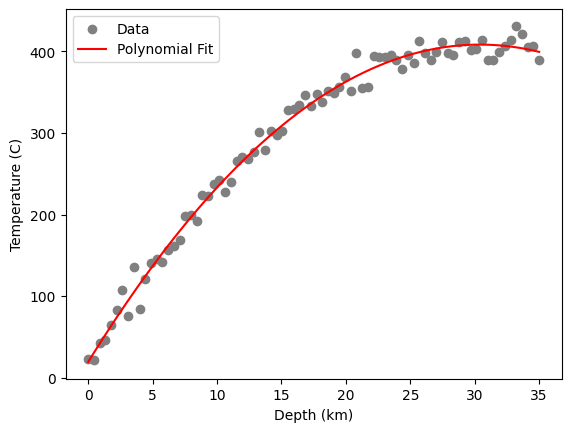

In [6]:
# Task 2: Polynomial Regression
X_temp = df_temp[['Depth_km']]
y_temp = df_temp['Temperature_C']

# Hint 1: Use PolynomialFeatures(degree=2) to transform X_temp
# Hint 2: Fit a LinearRegression model on the transformed X
### YOUR CODE HERE ###
poly = poly = PolynomialFeatures(degree=2)
X_poly = X_poly = poly.fit_transform(X_temp)
poly_model = LinearRegression()
poly_model.fit(X_poly, y_temp)


plt.scatter(X_temp, y_temp, color='gray', label='Data')
plt.plot(X_temp, poly_model.predict(X_poly), color='red', label='Polynomial Fit')
plt.xlabel('Depth (km)')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

## Part 3: Non-Parametric Tests for Nominal Data
**Dataset:** `df_volcanic` contains nominal/categorical data.
We want to know if the type of rock (Basalt vs Andesite) is independent of the tectonic setting (Mid-Ocean Ridge vs Subduction Zone).

**Task 3:** Create a contingency table and run a Chi-Square Test of Independence. Because our degrees of freedom is 1, ensure Yates' Correction for Continuity is applied (it is by default in SciPy!).

In [11]:
# Task 3: Chi-Square Test
# Hint 1: Use pd.crosstab() to make a contingency table from df_volcanic['Setting'] and df_volcanic['Rock_Type']
# Hint 2: Pass the table to scipy.stats.chi2_contingency()

### YOUR CODE HERE ###
contingency_table = pd.crosstab(df_volcanic['Setting'], df_volcanic['Rock_Type'])
print(contingency_table)
stat, p_val, dof, expected = stats.chi2_contingency(contingency_table, correction=True)
print(f"P-value: {p_val}")

Rock_Type        Andesite  Basalt
Setting                          
Mid-Ocean Ridge         5      55
Subduction Zone        25      15
P-value: 2.5776479007845493e-08


**Question 3 (Answer Below the Question) :**

1. Do we reject the null hypothesis that rock type is independent of setting?

The P-value is very small so, yes

## Part 4: Randomization Tests
**Dataset:** `fault_A_disp` and `fault_B_disp`
These arrays contain displacement measurements (in meters) from two fault zones. The sample sizes are very small, and the data is non-normal. Rather than a t-test, we will use a randomization (permutation) test to see if the means are significantly different.

**Task 4:** Calculate the observed difference in means. Then, pool the data, shuffle it 10,000 times, and calculate the difference in means for each shuffle. Find the p-value.

In [14]:
# Task 4: Randomization Test
obs_diff = np.abs(np.mean(fault_A_disp) - np.mean(fault_B_disp))
print(f"Observed Difference: {obs_diff:.3f} m")

n_A = len(fault_A_disp)
pooled_data = np.concatenate([fault_A_disp, fault_B_disp])
n_permutations = 10000
count_extreme = 0

# Hint: Loop n_permutations times. Inside the loop, use np.random.permutation(pooled_data).
# Split the shuffled data into two groups of sizes len(fault_A_disp) and len(fault_B_disp).
# Calculate the absolute difference in their means. If it's >= obs_diff, add 1 to count_extreme.

### YOUR CODE HERE ###
# for i in range(n_permutations):
for i in range(n_permutations):
    shuffled = np.random.permutation(pooled_data)
    group_A = shuffled[:n_A]
    group_B = shuffled[n_A:]
    perm_diff = np.abs(np.mean(group_A) - np.mean(group_B))
    if perm_diff >= obs_diff:
        count_extreme += 1
p_value = count_extreme / n_permutations
print(f"Randomization Test P-value: {p_value}")

Observed Difference: 1.179 m
Randomization Test P-value: 0.0109


## Part 5: Cross-Validation & Resampling
Let's return to our Multiple Linear Regression model from Part 1. How do we know our R-squared isn't just an artifact of the specific data points we sampled? We can use K-Fold Cross-Validation.

**Task 5:** Perform a 5-fold cross-validation on the Multiple Linear Regression model (Predicting `y` from `X_multiple`). Calculate the mean R-squared score across all 5 folds.

In [16]:
# Task 5: K-Fold Cross Validation
# Hint 1: Use KFold(n_splits=5, shuffle=True, random_state=42)
# Hint 2: Use cross_val_score(model, X, y, cv=kf)
model = LinearRegression()
### YOUR CODE HERE ###
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_multiple, y, cv=kf)
print(f"Cross-Validation R^2 Scores: {cv_scores}")
print(f"Mean CV R^2: {np.mean(cv_scores):.3f}")

Cross-Validation R^2 Scores: [-0.77989174  0.01134661  0.09751448  0.00992461 -0.53588963]
Mean CV R^2: -0.239


## Part 6: Checking Linear Regression Assumptions (Residual Analysis)
**Context:** In Lecture 17, we learned that for a linear regression model to be valid, the residuals (the differences between the observed and predicted values) must be normally and evenly distributed about the regression line. If the variance of the residuals changes as the predicted values change, we have **heteroscedasticity**.

**Task 6:** 1. Use your multiple linear regression model from Part 1 (`model_multiple`) to generate predicted porosity values (`y_pred`).
2. Calculate the residuals ($Residual = Actual - Predicted$).
3. Create a scatter plot of the Predicted Values (x-axis) versus the Residuals (y-axis). Add a horizontal dashed line at y=0.

*Note: If you haven't run Part 1 recently, the code cell below will quickly re-fit the model for you.*

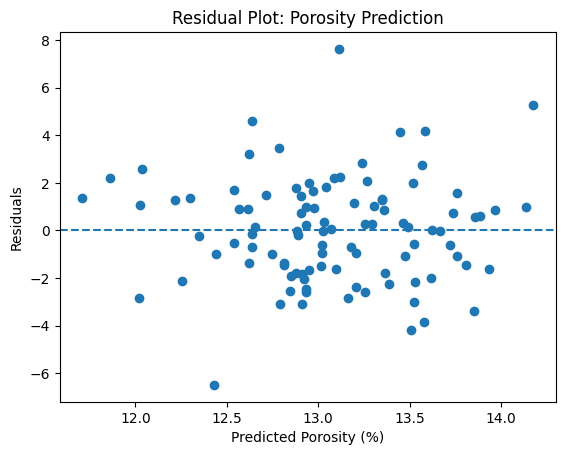

In [17]:
# Task 6: Residual Analysis Plot

# Re-fitting the model from Part 1 just in case
X_multiple = df_core[['Density_gcm3', 'Depth_m']]
y = df_core['Porosity_pct']
model_multiple = LinearRegression().fit(X_multiple, y)

# 1. Calculate predicted values
### YOUR CODE HERE ###
y_pred = model_multiple.predict(X_multiple)

# 2. Calculate residuals
### YOUR CODE HERE ###
residuals = y - y_pred

# 3. Plot Residuals vs Predicted Values
### YOUR CODE HERE ###
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Porosity (%)')
plt.ylabel('Residuals')
plt.title('Residual Plot: Porosity Prediction')
plt.show()

**Question 6 (Answer Below Each Question):**
Look at the residual plot you generated.
1. Do the residuals appear as an even scatter in a horizontal band above and below zero?

Yes

2. Is there any visual evidence of heteroscedasticity (e.g., the spread of residuals widening or narrowing at higher predicted values)?

No

3. Based on this, does our multiple linear regression model satisfy the assumption of evenly distributed residuals?

Yes

## Part 7: The G-test of Log-Likelihood Ratio
**Dataset Generation (Paleontology):** We have collected counts of two different index fossils (Ammonite Species A and Ammonite Species B) from two different stratigraphic layers (Lower Shale vs Upper Shale).

**Context:** In Lecture 18, we discussed the G-test of log-likelihood ratio. Like the Chi-square test, it is used for nominal scale data to test for independence, but it is based on maximum likelihood.

**Task 7:** 1. Create a contingency table using the provided fossil dataset.
2. Run a G-test. In SciPy, you can perform a G-test using the same `chi2_contingency` function from Part 3, but by passing the argument `lambda_='log-likelihood'`.

In [19]:
# Task 7: G-test
# Creating the dataset
df_fossils = pd.DataFrame({
    'Stratum': ['Lower Shale']*45 + ['Upper Shale']*55,
    'Fossil_Species': ['Species A']*35 + ['Species B']*10 + ['Species A']*15 + ['Species B']*40
})

# 1. Create a contingency table using pd.crosstab()
### YOUR CODE HERE ###
fossil_table = pd.crosstab(df_fossils['Stratum'], df_fossils['Fossil_Species'])
print(fossil_table)

# 2. Perform the G-test using chi2_contingency with lambda_='log-likelihood'
### YOUR CODE HERE ###
# g_stat, p_val_g, dof_g, expected_g = scipy.stats.chi2_contingency(..., lambda_='log-likelihood')
g_stat, p_val_g, dof_g, expected_g = stats.chi2_contingency(fossil_table, lambda_='log-likelihood')
print(f"G-Statistic: {g_stat:.3f}")
print(f"P-value: {p_val_g:.5f}")

Fossil_Species  Species A  Species B
Stratum                             
Lower Shale            35         10
Upper Shale            15         40
G-Statistic: 24.322
P-value: 0.00000


**Question 7 (Answer below the questions):**
1. Based on your P-value from the G-test, are the fossil species independent of the stratigraphic layer? (Assume $\alpha = 0.05$).

The P-value is 0, 0<0.05 so we reject the null hypothesis. Meaning that the fossil species are not independant of the stratigraphiic layer.

2. According to Lecture 18, what specific correction factor is often applied to the G-test statistic when sample sizes are relatively small to prevent a Type I error?

Use the Williams Correction, adjusting the G-stat down slightly to account for smaller sample sizes